# Create report figures

Notebook này tạo các hình ablation bằng matplotlib và lưu vào `reports/figures` để LaTeX chỉ cần `includegraphics`.

In [7]:
from pathlib import Path
import os

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'reports').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

os.chdir(PROJECT_ROOT)
os.environ.setdefault('MPLCONFIGDIR', str(PROJECT_ROOT / '.matplotlib_cache'))
print(PROJECT_ROOT)

/Users/ngocbao/Documents/Document/research/main/speech/exps/demo


In [8]:
import matplotlib.pyplot as plt
import numpy as np

FIGURE_DIR = PROJECT_ROOT / 'reports' / 'figures'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

STYLE = [
    {'color': '#f6b0ad', 'hatch': 'o'},
    {'color': '#b7d7e8', 'hatch': '||'},
    {'color': '#bfe8bf', 'hatch': '-'},
    {'color': '#d9c3df', 'hatch': 'x'},
    {'color': '#ffd59b', 'hatch': '/'},
    {'color': '#fff9b8', 'hatch': '+'},
    {'color': '#e8dcc5', 'hatch': '\\'},
]

def plot_ablation(labels, values, title, output_name):
    fig, ax = plt.subplots(figsize=(4.8, 2.6))
    x = np.arange(len(labels))
    for idx, (label, value) in enumerate(zip(labels, values)):
        style = STYLE[idx % len(STYLE)]
        ax.bar(
            x[idx], value, width=0.72, label=label,
            color=style['color'], edgecolor='#222222', linewidth=0.8,
            hatch=style['hatch'], zorder=3,
        )
        ax.text(x[idx], value + 1.0, f'{value:.0f}', ha='center', va='bottom', fontsize=7)
    ax.set_ylabel('UA (%)', fontsize=8)
    ax.set_ylim(0, 100)
    ax.set_xticks([])
    ax.tick_params(axis='y', labelsize=8)
    ax.grid(axis='y', linestyle='--', linewidth=0.5, alpha=0.45, zorder=0)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(
        loc='upper center', bbox_to_anchor=(0.5, 1.22),
        ncol=min(3, len(labels)), frameon=True, fontsize=7,
        columnspacing=1.0, handlelength=1.6,
    )
    fig.tight_layout(rect=(0, 0, 1, 0.92))
    out = FIGURE_DIR / output_name
    fig.savefig(out, dpi=300, bbox_inches='tight')
    plt.show()
    print(out)

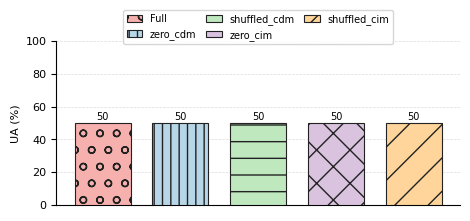

/Users/ngocbao/Documents/Document/research/main/speech/exps/demo/reports/figures/memory_ablation.png


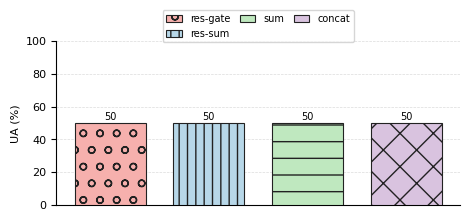

/Users/ngocbao/Documents/Document/research/main/speech/exps/demo/reports/figures/fusion_ablation.png


In [9]:
plot_ablation(
    labels=['Full', 'zero_cdm', 'shuffled_cdm', 'zero_cim', 'shuffled_cim'],
    values=[50, 50, 50, 50, 50],
    title='Memory ablation',
    output_name='memory_ablation.png',
)

plot_ablation(
    labels=['res-gate', 'res-sum', 'sum', 'concat'],
    values=[50, 50, 50, 50],
    title='Fusion ablation',
    output_name='fusion_ablation.png',
)